In [1]:
library(dplyr)
library(Matrix)
library(data.table)
library(Seurat)
library(ggplot2)
library(RColorBrewer)
cols = c(brewer.pal(9, "Set1"),brewer.pal(8,"Set2")[1:8],brewer.pal(12,"Paired")[1:12],brewer.pal(8,"Dark2")[1:8],brewer.pal(8,"Accent"),brewer.pal(12, "Set3"),brewer.pal(9,"Pastel1"),brewer.pal(8,"Pastel2"))
celltype = c("L2 IT neurons", "L2/3 IT neurons", "L3 IT neurons", "L3-6 IT neurons", "L3/4 IT neurons", 
 "L4 IT neurons", "L4/5 IT neurons", "L5 ET neurons", "L5/6 CAR3 neurons", "L5/6 NP neurons", 
 "L6 CT neurons", "L6 IT neurons", "L6b neurons", "LAMP5 neurons", "PVALB Chandelier neurons", 
 "PVALB neurons", "RELN neurons", "SST CHODL neurons", "SST neurons", "VIP neurons", 
 "Astrocytes", "Microglia", "Oligodendrocyte precursor cells", "Oligodendrocytes", 
 "Vascular cells")

best_color = c("#EA5514", "#D23918", "#FFB400", "#99F880", "#da32e9", 
 "#00e2ff", "#832aff", "#008396", "#01fac9", "#940202", 
 "#01fa65", "#00adff", "#058d32", "#c10265", "#bea013", 
 "#bcbe13", "#FF0000", "#ebb076", "#fa5a03", "#e06565", 
 "#7E9853", "#6565bc", "#b5a48d", "#90734e", "#88C6CE")

names(best_color) = celltype


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘Matrix’ was built under R version 4.2.3”

Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


The legacy packages maptools, rgdal, and rgeos, underpinning this package
will retire shortly. Please refer to R-spatial evolution reports on
https://r-spatial.org/r/2023/05/15/evolution4.html for details.
This package is now running under evolution status 0 

Attaching SeuratObject



In [2]:
profile = "T993"
celldata = readRDS(paste0('/data/',profile,'cellbin.rds'))
meta = readRDS(paste0('/data/',profile,'cellbin_meta.rds'))
celldata$Cellid = rownames(celldata@meta.data)
celldata = subset(celldata,Cellid%in%rownames(meta))
celldata@meta.data = meta
saveRDS(celldata,paste0('/data/',profile,'cellbin_addmeta.rds'))

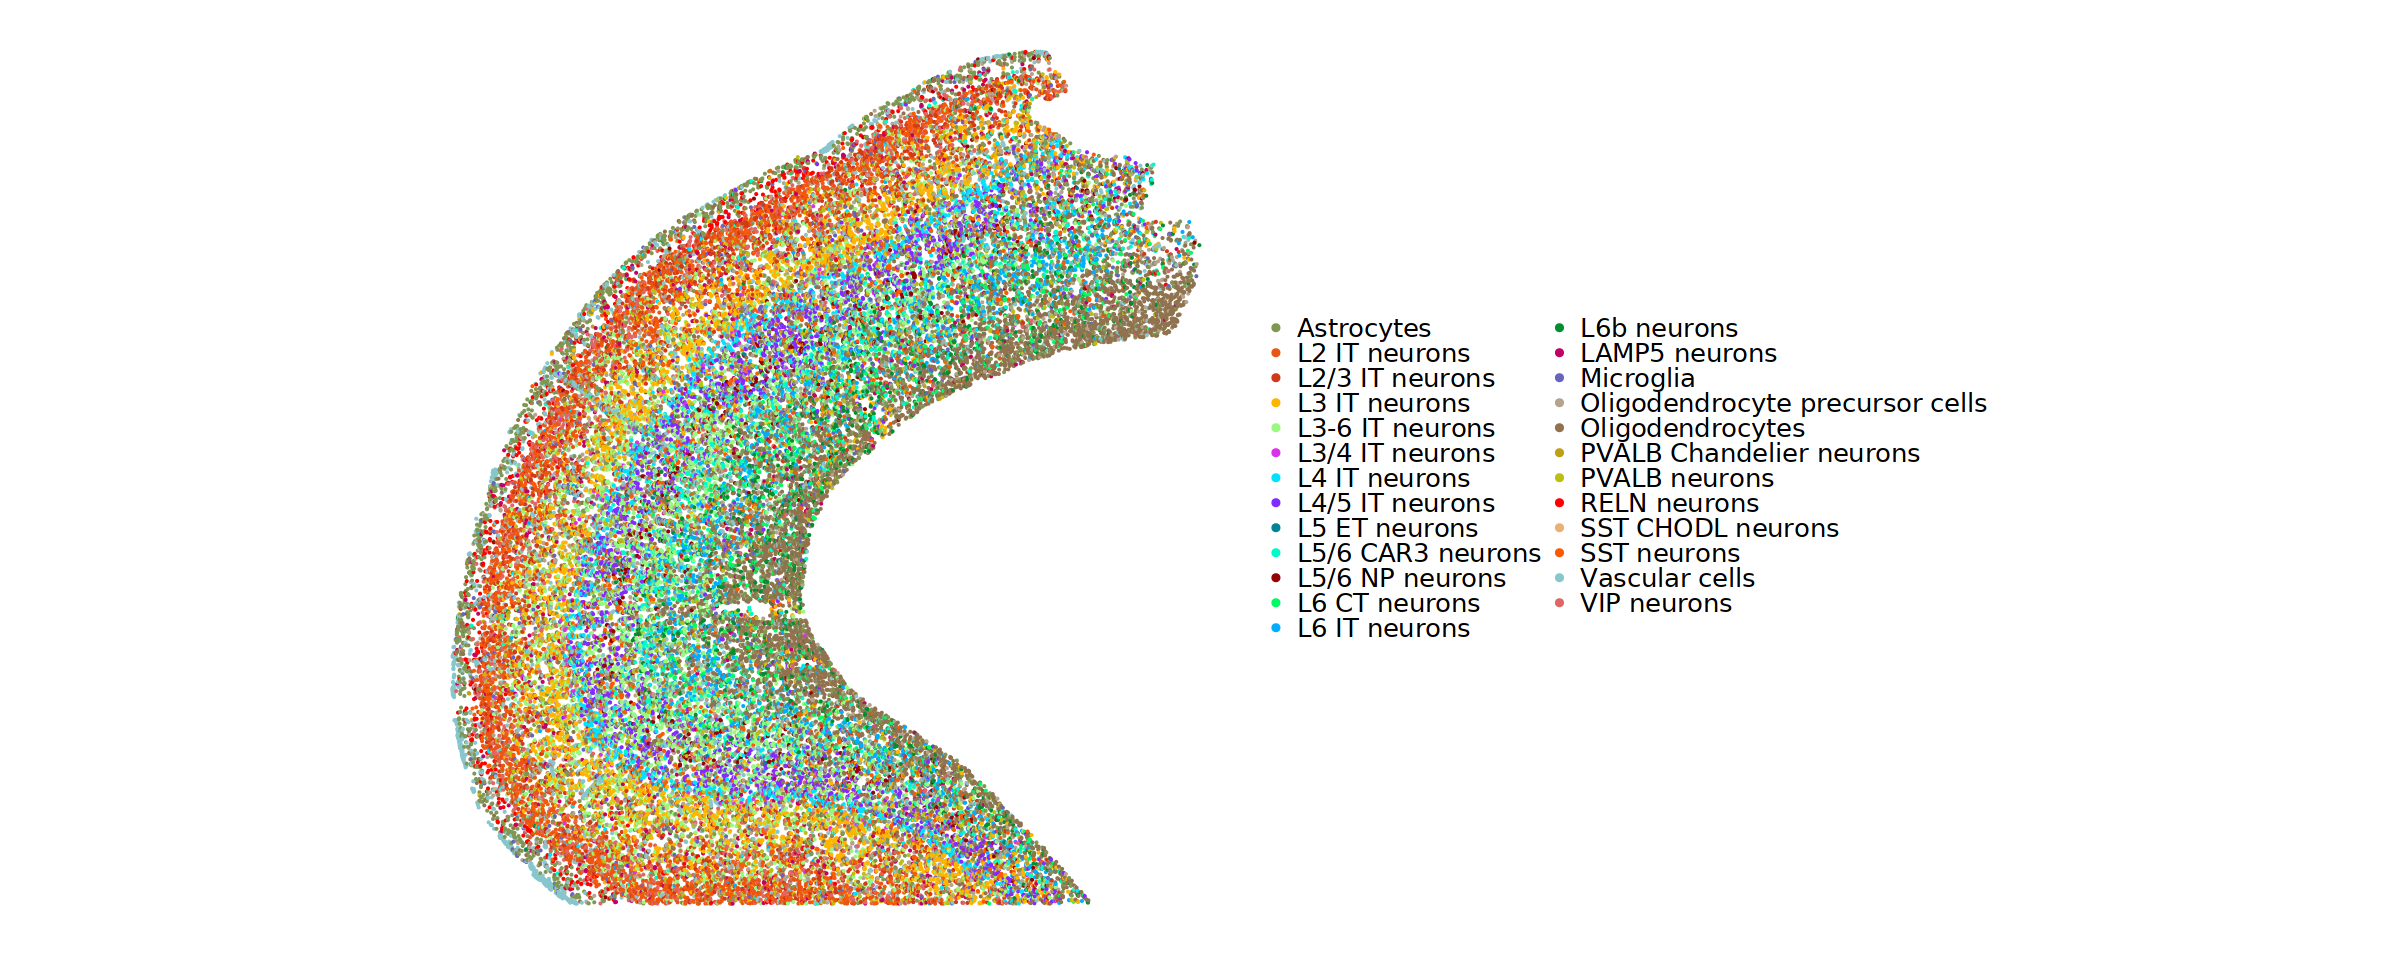

In [3]:
options(repr.plot.width=20, repr.plot.height=8) 
ggplot(data=celldata@meta.data,aes(x= coor_x , y = coor_y ,color = CellType_Spatialid)) +  
  geom_point(size=0.1) + 
  scale_color_manual(values = best_color) + 
  coord_fixed() +
  theme(panel.grid.major = element_blank(), 
          panel.grid.minor = element_blank(), 
          panel.border = element_blank(),
          axis.title = element_blank(),  
          axis.text = element_blank(), 
          axis.ticks = element_blank(),
          panel.background = element_rect(fill = 'white'),
          plot.background=element_rect(fill="white")) + 
          theme(legend.title = element_blank(), 
                legend.key=element_rect(fill='white'), #
                legend.text = element_text(size=15), 
                legend.key.size=unit(0.5,'cm'),
               text = element_text(size =15)) +  
          guides(color = guide_legend(override.aes = list(size=1.5))) 